# 🏥 VLM Knowledge Distillation on VQA-RAD
## Teacher: BLIP (Salesforce/blip-vqa-base) → Student: MobileNetV2

**Pipeline Overview:**
1. Install dependencies & imports
2. Load & preprocess VQA-RAD dataset
3. Train/Test/Validation splits
4. Baseline accuracy — Teacher (BLIP)
5. Baseline accuracy — Student (MobileNetV2, no KD)
6. Knowledge Distillation training
7. Post-KD Student accuracy
8. Sample visualization & comparison


## 1. Install Dependencies

In [2]:
# Install required packages (compatible with Kaggle P100/T4 GPU)
!pip install -q transformers datasets torch torchvision Pillow matplotlib seaborn scikit-learn tqdm
# BLIP is available through transformers >= 4.15  (already on Kaggle)
import subprocess, sys
result = subprocess.run([sys.executable, "-c", "import transformers; print(transformers.__version__)"],
                       capture_output=True, text=True)
print("transformers version:", result.stdout.strip())
print("\u2705 All dependencies ready.")


transformers version: 4.33.0
✅ All dependencies ready.


## 2. Imports & Configuration

In [3]:
import os
import json
import random
import warnings
import time
import pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms

from transformers import BlipProcessor, BlipForQuestionAnswering

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# NLG metrics
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt',   quiet=True)

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

try:
    from nltk.translate.meteor_score import meteor_score as _meteor_fn
    def meteor_score(ref_list, hyp): return _meteor_fn(ref_list, hyp)
    print("METEOR: nltk backend")
except ImportError:
    import math
    def meteor_score(ref_list, hyp):
        ref = set(ref_list[0]) if ref_list else set()
        h   = set(hyp)
        if not h or not ref: return 0.0
        hits = len(ref & h)
        if hits == 0: return 0.0
        p = hits/len(h); r = hits/len(ref)
        f = (10*p*r)/(9*p+r+1e-9)
        pen = 0.5*(max(0, len(hyp)/max(len(ref),1)-1)**3)
        return f * math.exp(-pen)
    print("METEOR: manual unigram fallback")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\u1f5a5\ufe0f  Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")


METEOR: manual unigram fallback
὚5️  Device: cuda
   GPU: Tesla T4


## 3. Download VQA-RAD Dataset from Kaggle

In [4]:
import os

KAGGLE_INPUT = '/kaggle/input/vqa-rad-visual-question-answering-radiology'

if os.path.exists(KAGGLE_INPUT):
    DATA_DIR = KAGGLE_INPUT
    print(f"\u2705 Using Kaggle input: {DATA_DIR}")
else:
    os.makedirs('./vqa_rad_data', exist_ok=True)
    os.system('kaggle datasets download -d shashankshekhar1205/vqa-rad-visual-question-answering-radiology --unzip -p ./vqa_rad_data')
    DATA_DIR = './vqa_rad_data'
    print(f"\u2705 Downloaded to: {DATA_DIR}")

print("\n\U0001f4c1 Dataset contents:")
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for f in files[:10]:
        print(f"{subindent}{f}")
    if len(files) > 10:
        print(f"{subindent}... and {len(files)-10} more files")


✅ Using Kaggle input: /kaggle/input/vqa-rad-visual-question-answering-radiology

📁 Dataset contents:
vqa-rad-visual-question-answering-radiology/
  VQA_RAD Dataset Public.xml
  VQA_RAD Dataset Public.json
  Readme.docx
  VQA_RAD Dataset Public.xlsx
  VQA_RAD Image Folder/
    synpic34854.jpg
    synpic57935.jpg
    synpic50848.jpg
    synpic53097.jpg
    synpic47737.jpg
    synpic45557.jpg
    synpic58902.jpg
    synpic22037.jpg
    synpic27047.jpg
    synpic46976.jpg
    ... and 305 more files


## 4. Load & Explore the Dataset

In [5]:
def find_json_files(base_dir):
    json_files = []
    for root, _, files in os.walk(base_dir):
        for f in files:
            if f.endswith('.json') or f.endswith('.jsonl'):
                json_files.append(os.path.join(root, f))
    return json_files

def find_image_dir(base_dir):
    for root, dirs, files in os.walk(base_dir):
        imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if len(imgs) > 10:
            return root, imgs
    return base_dir, []

json_files = find_json_files(DATA_DIR)
print("JSON files found:", json_files)

img_dir, img_list = find_image_dir(DATA_DIR)
print(f"Image directory: {img_dir}")
print(f"Total images found: {len(img_list)}")


JSON files found: ['/kaggle/input/vqa-rad-visual-question-answering-radiology/VQA_RAD Dataset Public.json']
Image directory: /kaggle/input/vqa-rad-visual-question-answering-radiology/VQA_RAD Image Folder
Total images found: 315


In [6]:
def load_annotations(json_files):
    all_data = []
    for jf in json_files:
        try:
            with open(jf, 'r') as f:
                content = f.read().strip()
                if content.startswith('['):
                    data = json.loads(content)
                else:
                    data = [json.loads(line) for line in content.split('\n') if line.strip()]
            all_data.extend(data)
            print(f"  Loaded {len(data)} samples from {os.path.basename(jf)}")
        except Exception as e:
            print(f"  \u26a0\ufe0f Could not load {jf}: {e}")
    return all_data

raw_data = load_annotations(json_files)
print(f"\n\u2705 Total QA pairs loaded: {len(raw_data)}")
if raw_data:
    print("\nSample entry keys:", list(raw_data[0].keys()))
    print("\nSample entry:")
    print(json.dumps(raw_data[0], indent=2))


  Loaded 2248 samples from VQA_RAD Dataset Public.json

✅ Total QA pairs loaded: 2248

Sample entry keys: ['qid', 'phrase_type', 'qid_linked_id', 'image_case_url', 'image_name', 'image_organ', 'evaluation', 'question', 'question_rephrase', 'question_relation', 'question_frame', 'question_type', 'answer', 'answer_type']

Sample entry:
{
  "qid": "0",
  "phrase_type": "freeform",
  "qid_linked_id": "03f451ca-de62-4617-9679-e836026a7642",
  "image_case_url": "https://medpix.nlm.nih.gov/case?id=48e1dd0e-8552-46ad-a354-5eb55be86de6",
  "image_name": "synpic54610.jpg",
  "image_organ": "HEAD",
  "evaluation": "not evaluated",
  "question": "Are regions of the brain infarcted?",
  "question_rephrase": "NULL",
  "question_relation": "NULL",
  "question_frame": "NULL",
  "question_type": "PRES",
  "answer": "Yes",
  "answer_type": "CLOSED"
}


In [7]:
def build_dataframe(raw_data, img_dir):
    rows = []
    for item in raw_data:
        img_name = item.get('image_name', item.get('image', item.get('img_id', '')))
        question = item.get('question', item.get('Question', ''))
        answer = item.get('answer', item.get('Answer', ''))
        qtype = item.get('question_type', item.get('answer_type', 'unknown'))
        phrase_type = item.get('phrase_type', '')
        img_path = None
        for ext in ['', '.jpg', '.jpeg', '.png']:
            candidate = os.path.join(img_dir, str(img_name) + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break
        rows.append({
            'image_name': str(img_name),
            'image_path': img_path,
            'question': str(question),
            'answer': str(answer).strip().lower(),
            'question_type': str(qtype).lower(),
            'phrase_type': str(phrase_type).lower()
        })
    df = pd.DataFrame(rows)
    df = df[df['image_path'].notna()].reset_index(drop=True)
    return df

df = build_dataframe(raw_data, img_dir)
print(f"DataFrame shape: {df.shape}")
df.head()


DataFrame shape: (2248, 6)


,image_name,image_path,question,answer,question_type,phrase_type
0,synpic54610.jpg,/kaggle/input/vqa-rad-visual-question-answerin...,Are regions of the brain infarcted?,yes,pres,freeform
1,synpic29265.jpg,/kaggle/input/vqa-rad-visual-question-answerin...,Are the lungs normal appearing?,no,abn,freeform
2,synpic29265.jpg,/kaggle/input/vqa-rad-visual-question-answerin...,Is there evidence of a pneumothorax,no,pres,freeform
3,synpic28602.jpg,/kaggle/input/vqa-rad-visual-question-answerin...,What type of imaging does this not represent?,ultrasound,modality,freeform
4,synpic29265.jpg,/kaggle/input/vqa-rad-visual-question-answerin...,Is this a MRI of the chest?,no,modality,freeform


In [8]:
print("=" * 55)
print("\U0001f4ca DATASET STATISTICS")
print("=" * 55)
print(f"Total QA pairs:      {len(df)}")
print(f"Unique images:       {df['image_name'].nunique()}")
print(f"Unique answers:      {df['answer'].nunique()}")
print(f"\nQuestion types:\n{df['question_type'].value_counts()}")
print(f"\nTop 20 answers:")
print(df['answer'].value_counts().head(20))


📊 DATASET STATISTICS
Total QA pairs:      2248
Unique images:       314
Unique answers:      517

Question types:
question_type
pres            800
pos             316
abn             202
other           196
modality        185
size            171
plane           120
attrib           87
organ            59
color            52
count            24
pos, pres         6
pres, attrib      6
pres, pos         4
attrib, pres      4
abn, pos          3
pos, abn          2
size, color       2
color, pres       2
size, pres        2
pres, color       1
atrib             1
pres, abn         1
attrib, size      1
prse              1
Name: count, dtype: int64

Top 20 answers:
answer
no                                      606
yes                                     587
axial                                    43
right                                    26
left                                     19
pa                                       15
brain                                    13
ct            

## 5. Prepare Labels & Train/Val/Test Splits

In [9]:
TOP_N_ANSWERS = 50

top_answers = df['answer'].value_counts().head(TOP_N_ANSWERS).index.tolist()
df_filtered = df[df['answer'].isin(top_answers)].copy().reset_index(drop=True)

MIN_SAMPLES_PER_CLASS = 6
counts = df_filtered['answer'].value_counts()
valid_answers = counts[counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
removed = len(counts) - len(valid_answers)
df_filtered = df_filtered[df_filtered['answer'].isin(valid_answers)].copy().reset_index(drop=True)
print(f"Removed {removed} rare classes with fewer than {MIN_SAMPLES_PER_CLASS} samples.")

le = LabelEncoder()
df_filtered['label'] = le.fit_transform(df_filtered['answer'])
NUM_CLASSES = len(le.classes_)

print(f"Filtered to top-{TOP_N_ANSWERS} answers (after rare-class removal)")
print(f"Remaining samples : {len(df_filtered)}")
print(f"Number of classes : {NUM_CLASSES}")
print(f"Classes (first 10): {list(le.classes_[:10])} ...")

df_train, df_temp = train_test_split(
    df_filtered, test_size=0.30, random_state=SEED, stratify=df_filtered['label']
)

temp_counts = df_temp['label'].value_counts()
if temp_counts.min() >= 2:
    df_val, df_test = train_test_split(
        df_temp, test_size=0.50, random_state=SEED, stratify=df_temp['label']
    )
    print("\n\u2705 Both splits used stratified sampling.")
else:
    df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=SEED)
    print("\n\u26a0\ufe0f  Val/Test used random (non-stratified).")

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"\n\U0001f4ca Final split sizes:")
print(f"   Train : {len(df_train):>5}  ({len(df_train)/len(df_filtered)*100:.1f}%)")
print(f"   Val   : {len(df_val):>5}  ({len(df_val)/len(df_filtered)*100:.1f}%)")
print(f"   Test  : {len(df_test):>5}  ({len(df_test)/len(df_filtered)*100:.1f}%)")


Removed 25 rare classes with fewer than 6 samples.
Filtered to top-50 answers (after rare-class removal)
Remaining samples : 1440
Number of classes : 25
Classes (first 10): ['5.6cm focal, predominantly hypodense', 'axial', 'bilateral', 'brain', 'ct', 'diffuse', 'fat', 'female', 'flair', 'lateral ventricles'] ...

✅ Both splits used stratified sampling.

📊 Final split sizes:
   Train :  1008  (70.0%)
   Val   :   216  (15.0%)
   Test  :   216  (15.0%)


## 6. Dataset & DataLoader Classes

In [10]:
# ── Image size constants ──────────────────────────────────────
BLIP_SIZE   = 384   # BLIP uses 384×384
MOBILE_SIZE = 224   # MobileNetV2 standard

# ── BLIP transform (simple resize + ToTensor; BLIP processor does normalisation internally)
blip_pil_transform = transforms.Compose([
    transforms.Resize((BLIP_SIZE, BLIP_SIZE)),
])

# ── MobileNetV2 transforms ────────────────────────────────────
mobile_transform_train = transforms.Compose([
    transforms.Resize((MOBILE_SIZE, MOBILE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

mobile_transform_eval = transforms.Compose([
    transforms.Resize((MOBILE_SIZE, MOBILE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


class VQARadDataset(Dataset):
    """
    Returns:
      pil_img      – raw PIL image (for BLIP processor)
      mobile_img   – normalised tensor for MobileNetV2
      label        – integer class index
      question     – question string
      answer       – ground-truth answer string
    """
    def __init__(self, df, mobile_transform=None):
        self.df = df.reset_index(drop=True)
        self.mobile_transform = mobile_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['image_path']).convert('RGB')
        except Exception:
            img = Image.fromarray(np.zeros((MOBILE_SIZE, MOBILE_SIZE, 3), dtype=np.uint8))

        mobile_img = self.mobile_transform(img) if self.mobile_transform else transforms.ToTensor()(img)
        label      = int(row['label'])

        return {
            'pil_img':    img,                                   # PIL – for BLIP
            'mobile_img': mobile_img,                            # tensor – for MobileNet
            'label':      torch.tensor(label, dtype=torch.long),
            'question':   row['question'],
            'answer':     row['answer']
        }


BATCH_SIZE = 16   # keep at 16 – BLIP+MobileNet both in memory

train_ds = VQARadDataset(df_train, mobile_transform_train)
val_ds   = VQARadDataset(df_val,   mobile_transform_eval)
test_ds  = VQARadDataset(df_test,  mobile_transform_eval)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True,
                          collate_fn=lambda x: x)   # list-of-dicts; we collate manually
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True,
                          collate_fn=lambda x: x)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True,
                          collate_fn=lambda x: x)

def collate_batch(batch_list):
    """Collate list-of-dicts into dict-of-tensors / lists."""
    return {
        'pil_img':    [b['pil_img']    for b in batch_list],
        'mobile_img': torch.stack([b['mobile_img'] for b in batch_list]),
        'label':      torch.stack([b['label']      for b in batch_list]),
        'question':   [b['question']   for b in batch_list],
        'answer':     [b['answer']     for b in batch_list],
    }

print("\u2705 DataLoaders ready")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val   batches : {len(val_loader)}")
print(f"   Test  batches : {len(test_loader)}")


✅ DataLoaders ready
   Train batches : 63
   Val   batches : 14
   Test  batches : 14


## 7. NLG Metric & Efficiency Helpers

In [11]:
def compute_bleu(refs, hyps):
    sf      = SmoothingFunction().method1
    ref_tok = [[r.lower().split()] for r in refs]
    hyp_tok = [h.lower().split()   for h in hyps]
    b1 = corpus_bleu(ref_tok, hyp_tok, weights=(1,0,0,0),        smoothing_function=sf)
    b4 = corpus_bleu(ref_tok, hyp_tok, weights=(.25,.25,.25,.25), smoothing_function=sf)
    return round(b1*100,2), round(b4*100,2)

def compute_meteor(refs, hyps):
    scores = [meteor_score([r.lower().split()], h.lower().split())
              for r, h in zip(refs, hyps)]
    return round(float(np.mean(scores))*100, 2)

def compute_cider(refs, hyps):
    from collections import defaultdict
    import math
    def ngrams(text, n=4):
        t=text.lower().split(); g=defaultdict(float)
        for k in range(1,n+1):
            for i in range(len(t)-k+1): g[' '.join(t[i:i+k])]+=1.0
        return g
    N=len(refs); df_cnt=defaultdict(int)
    for r in refs:
        for g in ngrams(r): df_cnt[g]+=1
    scores=[]
    for r,h in zip(refs,hyps):
        rg=ngrams(r); hg=ngrams(h); keys=set(rg)|set(hg)
        idf=lambda k: math.log((N+1)/(df_cnt.get(k,0)+1)+1)
        sim=sum(min(rg.get(k,0),hg.get(k,0))*idf(k) for k in keys)
        rn=sum(v*idf(k) for k,v in rg.items())
        hn=sum(v*idf(k) for k,v in hg.items())
        scores.append(sim/(rn*hn+1e-9)**0.5 if rn and hn else 0.0)
    return round(float(np.mean(scores))*10, 3)

def all_nlg(refs, hyps):
    b1,b4 = compute_bleu(refs, hyps)
    return {'BLEU-1':b1, 'BLEU-4':b4,
            'METEOR':compute_meteor(refs,hyps),
            'CIDEr' :compute_cider(refs,hyps)}

def model_size_mb(model):
    tmp='/tmp/_sz.pth'
    torch.save(model.state_dict(), tmp)
    mb=os.path.getsize(tmp)/1e6; os.remove(tmp)
    return round(mb,2)

def count_params_m(model):
    return round(sum(p.numel() for p in model.parameters())/1e6, 2)

def gpu_mem_mb(device):
    if device.type!='cuda': return 0.0
    return round(torch.cuda.max_memory_allocated(device)/1e6, 1)

print("\u2705 NLG + Efficiency helpers ready.")


✅ NLG + Efficiency helpers ready.


## 8. Teacher Model — BLIP (Salesforce/blip-vqa-base)

**Why BLIP?**
- Purpose-built for Visual Question Answering (VQA)
- ~385M parameters – much lighter than CLIP-ViT-L (~430M) yet stronger on VQA tasks
- Ships directly with HuggingFace `transformers` – no extra package needed
- Runs comfortably on Kaggle P100/T4 with batch_size=16


In [12]:
# ── Load BLIP for VQA ────────────────────────────────────────
MODEL_NAME = "Salesforce/blip-vqa-base"
print(f"\u23f3 Loading {MODEL_NAME} ...")

blip_processor = BlipProcessor.from_pretrained(MODEL_NAME)
blip_base      = BlipForQuestionAnswering.from_pretrained(MODEL_NAME)
blip_base      = blip_base.to(DEVICE)

# The BLIP VQA model has a vision encoder + text encoder + decoder.
# vision_model output dim = 768 (ViT-B/16 backbone inside BLIP)
BLIP_EMBED_DIM = blip_base.config.vision_config.hidden_size   # 768
print(f"\u2705 BLIP loaded.  Vision embed dim = {BLIP_EMBED_DIM}")
print(f"   Total params ≈ {sum(p.numel() for p in blip_base.parameters())/1e6:.0f}M")


⏳ Loading Salesforce/blip-vqa-base ...


✅ BLIP loaded.  Vision embed dim = 768
   Total params ≈ 385M


In [13]:
class TeacherBLIP(nn.Module):
    """
    BLIP-VQA-base teacher wrapper.

    Forward pass:
      1. Run BLIP's vision encoder on the image  → image features [B, seq, 768]
      2. Mean-pool to get a single [B, 768] embedding
      3. Feed through deep MLP head → class logits [B, num_classes]

    The last 3 blocks of the vision encoder are fine-tuned;
    everything else is frozen.  The text encoder / decoder
    is NOT used during KD training — we treat BLIP as a
    strong visual feature extractor for this classification task.
    """
    def __init__(self, blip_model, embed_dim, num_classes):
        super().__init__()
        self.vision_model = blip_model.vision_model   # ViT-B inside BLIP
        self.embed_dim    = embed_dim

        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 1024),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(1024, 512),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(512, num_classes)
        )

    def get_image_features(self, pixel_values):
        """Return [B, embed_dim] pooled image features."""
        out   = self.vision_model(pixel_values=pixel_values)
        # last_hidden_state: [B, seq_len, 768]; mean-pool over seq dimension
        feats = out.last_hidden_state.mean(dim=1)   # [B, 768]
        return feats.float()

    def forward(self, pixel_values):
        feats  = self.get_image_features(pixel_values)   # [B, 768]
        logits = self.classifier(feats)                   # [B, num_classes]
        return logits, feats


teacher = TeacherBLIP(blip_base, BLIP_EMBED_DIM, NUM_CLASSES).to(DEVICE)

# ── Freeze ALL vision encoder params first ────────────────────
for p in teacher.vision_model.parameters():
    p.requires_grad = False

# ── Unfreeze last 3 transformer blocks ───────────────────────
UNFREEZE_LAST_N = 3
encoder_layers = teacher.vision_model.encoder.layers
for layer in encoder_layers[-UNFREEZE_LAST_N:]:
    for p in layer.parameters(): p.requires_grad = True

# ── Unfreeze post-layer norm ─────────────────────────────────
if hasattr(teacher.vision_model, 'post_layernorm'):
    for p in teacher.vision_model.post_layernorm.parameters():
        p.requires_grad = True

# ── Classifier always trainable ───────────────────────────────
for p in teacher.classifier.parameters():
    p.requires_grad = True

frozen    = sum(p.numel() for p in teacher.vision_model.parameters() if not p.requires_grad) / 1e6
trainable = sum(p.numel() for p in teacher.parameters() if p.requires_grad) / 1e6
print(f"\n\u2705 TeacherBLIP ready.")
print(f"   Frozen    : {frozen:.1f}M params")
print(f"   Trainable : {trainable:.2f}M params (last {UNFREEZE_LAST_N} blocks + LN + head)")



✅ TeacherBLIP ready.
   Frozen    : 64.8M params
   Trainable : 22.59M params (last 3 blocks + LN + head)


### 8.1 BLIP Processor Helper & Training Loop

In [58]:
def process_blip_batch(pil_images, questions, device):
    """
    Use BlipProcessor to convert PIL images + questions into pixel_values tensor.
    Returns pixel_values: [B, 3, 384, 384] on `device`.
    """
    inputs = blip_processor(
        images=pil_images,
        text=questions,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=32
    )
    return inputs['pixel_values'].to(device)


def train_one_epoch_teacher(model, loader, optimizer, criterion, device, scheduler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for raw_batch in tqdm(loader, leave=False):
        batch = collate_batch(raw_batch)
        labels = batch['label'].to(device)
        pixel_values = process_blip_batch(batch['pil_img'], batch['question'], device)

        optimizer.zero_grad()
        logits, _ = model(pixel_values)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()          # <-- step every batch, not every epoch

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate_teacher(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for raw_batch in loader:
        batch = collate_batch(raw_batch)
        labels = batch['label'].to(device)
        pixel_values = process_blip_batch(batch['pil_img'], batch['question'], device)

        logits, _ = model(pixel_values)
        loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / total, correct / total, all_preds, all_labels


# ── Training config ───────────────────────────────────────────
TEACHER_EPOCHS = 30

backbone_params = [p for p in teacher.vision_model.parameters() if p.requires_grad]
head_params     = list(teacher.classifier.parameters())

teacher_optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 2e-5,  'weight_decay': 1e-4},  # was 5e-6, too low to move
    {'params': head_params,     'lr': 3e-4,  'weight_decay': 1e-3},
])

scheduler_t = torch.optim.lr_scheduler.OneCycleLR(
    teacher_optimizer,
    max_lr=[2e-5, 3e-4],
    epochs=TEACHER_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

teacher_train_losses, teacher_val_losses = [], []
teacher_train_accs,   teacher_val_accs   = [], []
best_val_acc = 0.0
patience, no_improve = 8, 0   # early stopping so 51 epochs doesn't waste time once it plateaus

print("🎓 Training Teacher (BLIP-VQA-base) ...")
print(f"   Epochs={TEACHER_EPOCHS}  |  OneCycleLR  |  label_smoothing=0.1")
print(f"{'Epoch':<9}{'Train Loss':<14}{'Train Acc%':<14}{'Val Acc%':<13}Note")
print("-" * 58)

for epoch in range(1, TEACHER_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch_teacher(
        teacher, train_loader, teacher_optimizer, criterion, DEVICE, scheduler=scheduler_t)
    vl_loss, vl_acc, _, _ = evaluate_teacher(
        teacher, val_loader, criterion, DEVICE)

    teacher_train_losses.append(tr_loss)
    teacher_val_losses.append(vl_loss)
    teacher_train_accs.append(tr_acc)
    teacher_val_accs.append(vl_acc)

    flag = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(teacher.state_dict(), 'best_teacher_blip.pth')
        flag = "◄ best"
        no_improve = 0
    else:
        no_improve += 1

    print(f"  {epoch:<7}{tr_loss:<14.4f}{tr_acc*100:<14.2f}{vl_acc*100:<13.2f}{flag}")

    if no_improve >= patience:
        print(f"\n⏹ Early stopping: no improvement for {patience} epochs.")
        break

print("-" * 58)
print(f"\n✅ Teacher best val accuracy: {best_val_acc*100:.2f}%")

🎓 Training Teacher (BLIP-VQA-base) ...
   Epochs=30  |  OneCycleLR  |  label_smoothing=0.1
Epoch    Train Loss    Train Acc%    Val Acc%     Note
----------------------------------------------------------


  0%|          | 0/63 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


100%|██████████| 63/63 [01:32<00:00,  1.39s/it]

	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


...

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  8      1.3546        65.77         56.48        


  0%|          | 0/63 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  9      1.3224        66.17         56.94        

⏹ Early stopping: no improvement for 8 epochs.
----------------------------------------------------------

✅ Teacher best val accuracy: 57.87%


In [14]:
def process_blip_batch(pil_images, questions, device):
    """
    Use BlipProcessor to convert PIL images + questions into pixel_values tensor.
    Returns pixel_values: [B, 3, 384, 384] on `device`.
    """
    inputs = blip_processor(
        images=pil_images,
        text=questions,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=32
    )
    return inputs['pixel_values'].to(device)


def train_one_epoch_teacher(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for raw_batch in tqdm(loader, leave=False):
        batch  = collate_batch(raw_batch)
        labels = batch['label'].to(device)

        pixel_values = process_blip_batch(batch['pil_img'], batch['question'], device)

        optimizer.zero_grad()
        logits, _ = model(pixel_values)
        loss      = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate_teacher(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for raw_batch in loader:
        batch  = collate_batch(raw_batch)
        labels = batch['label'].to(device)

        pixel_values = process_blip_batch(batch['pil_img'], batch['question'], device)

        logits, _ = model(pixel_values)
        loss      = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        preds       = logits.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / total, correct / total, all_preds, all_labels


# ── Training config ───────────────────────────────────────────
TEACHER_EPOCHS = 51

backbone_params = [p for p in teacher.vision_model.parameters() if p.requires_grad]
head_params     = list(teacher.classifier.parameters())

teacher_optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 5e-6,  'weight_decay': 1e-4},
    {'params': head_params,     'lr': 2e-4,  'weight_decay': 1e-3},
])

scheduler_t = torch.optim.lr_scheduler.OneCycleLR(
    teacher_optimizer,
    max_lr=[5e-6, 2e-4],
    epochs=TEACHER_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

teacher_train_losses, teacher_val_losses = [], []
teacher_train_accs,   teacher_val_accs   = [], []
best_val_acc = 0.0

print("\U0001f393 Training Teacher (BLIP-VQA-base) ...")
print(f"   Epochs={TEACHER_EPOCHS}  |  OneCycleLR  |  label_smoothing=0.1")
print(f"{'Epoch':<9}{'Train Loss':<14}{'Train Acc%':<14}{'Val Acc%':<13}Note")
print("-" * 58)

for epoch in range(1, TEACHER_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch_teacher(
        teacher, train_loader, teacher_optimizer, criterion, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate_teacher(
        teacher, val_loader, criterion, DEVICE)
    scheduler_t.step()

    teacher_train_losses.append(tr_loss)
    teacher_val_losses.append(vl_loss)
    teacher_train_accs.append(tr_acc)
    teacher_val_accs.append(vl_acc)

    flag = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(teacher.state_dict(), 'best_teacher_blip.pth')
        flag = "\u25c4 best"

    print(f"  {epoch:<7}{tr_loss:<14.4f}{tr_acc*100:<14.2f}{vl_acc*100:<13.2f}{flag}")

print("-" * 58)
print(f"\n\u2705 Teacher best val accuracy: {best_val_acc*100:.2f}%")


🎓 Training Teacher (BLIP-VQA-base) ...
   Epochs=51  |  OneCycleLR  |  label_smoothing=0.1
Epoch    Train Loss    Train Acc%    Val Acc%     Note
----------------------------------------------------------


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  1      2.9901        34.13         42.13        ◄ best


  0%|          | 0/63 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  2      2.4664        42.46         43.52        ◄ best


...

	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  50     1.5995        58.43         57.87        


  0%|          | 0/63 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  51     1.5946        60.22         57.41        
----------------------------------------------------------

✅ Teacher best val accuracy: 59.72%


In [57]:
# ── Teacher Baseline Test Accuracy ───────────────────────────
teacher.load_state_dict(torch.load('best_teacher_blip.pth', map_location=DEVICE))
_, teacher_baseline_acc, t_preds, t_labels = evaluate_teacher(
    teacher, test_loader, criterion, DEVICE
)
print("=" * 55)
print(f"\U0001f393 TEACHER BASELINE ACCURACY (Test): {teacher_baseline_acc*100:.2f}%")
print("=" * 55)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
🎓 TEACHER BASELINE ACCURACY (Test): 57.87%


## 9. Student Model — MobileNetV2

In [16]:
class StudentMobileNet(nn.Module):
    """
    MobileNetV2 backbone + custom classification head.
    Also returns intermediate features for feature-level KD alignment.
    """
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        weights = models.MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
        base = models.mobilenet_v2(weights=weights)

        self.features   = base.features          # [B, 1280, 7, 7]
        self.pool       = nn.AdaptiveAvgPool2d(1) # → [B, 1280]
        self.embed_dim  = 1280

        # Project student features to match teacher BLIP embed dim (768) for KD
        self.proj = nn.Linear(self.embed_dim, BLIP_EMBED_DIM)

        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(self.embed_dim, num_classes)
        )

    def forward(self, x):
        feats  = self.pool(self.features(x)).flatten(1)  # [B, 1280]
        proj   = self.proj(feats)                         # [B, 768]
        logits = self.classifier(feats)                   # [B, num_classes]
        return logits, proj


def make_student(num_classes, pretrained=True):
    return StudentMobileNet(num_classes, pretrained).to(DEVICE)


_test_s = make_student(NUM_CLASSES)
total_s = sum(p.numel() for p in _test_s.parameters()) / 1e6
blip_total = sum(p.numel() for p in blip_base.parameters()) / 1e6
print(f"\u2705 StudentMobileNet ready.")
print(f"   Total params: {total_s:.2f}M")
print(f"   (BLIP teacher ≈{blip_total:.0f}M params — student is ≈{blip_total/total_s:.0f}× smaller)")
del _test_s


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 64.4MB/s]

✅ StudentMobileNet ready.
   Total params: 3.24M
   (BLIP teacher ≈385M params — student is ≈119× smaller)


### 9.1 Baseline Student Training (WITHOUT Knowledge Distillation)

In [30]:
STUDENT_EPOCHS = 2

student_baseline = make_student(NUM_CLASSES)
opt_sb = torch.optim.Adam(student_baseline.parameters(), lr=1e-3, weight_decay=1e-4)
sch_sb = torch.optim.lr_scheduler.CosineAnnealingLR(opt_sb, T_max=STUDENT_EPOCHS)

sb_train_losses, sb_val_losses = [], []
sb_train_accs,   sb_val_accs   = [], []


def train_student_baseline(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for raw_batch in tqdm(loader, leave=False):
        batch  = collate_batch(raw_batch)
        imgs   = batch['mobile_img'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        logits, _ = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_student(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for raw_batch in loader:
        batch  = collate_batch(raw_batch)
        imgs   = batch['mobile_img'].to(device)
        labels = batch['label'].to(device)
        logits, _ = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / total, correct / total, all_preds, all_labels


print("\U0001f4f1 Training Student Baseline (no KD) ...")
best_sb_acc = 0.0

for epoch in range(1, STUDENT_EPOCHS + 1):
    tr_loss, tr_acc = train_student_baseline(student_baseline, train_loader, opt_sb, criterion, DEVICE)
    vl_loss, vl_acc, _, _ = eval_student(student_baseline, val_loader, criterion, DEVICE)
    sch_sb.step()

    sb_train_losses.append(tr_loss)
    sb_val_losses.append(vl_loss)
    sb_train_accs.append(tr_acc)
    sb_val_accs.append(vl_acc)

    if vl_acc > best_sb_acc:
        best_sb_acc = vl_acc
        torch.save(student_baseline.state_dict(), 'best_student_baseline.pth')

    print(f"  Epoch [{epoch:02d}/{STUDENT_EPOCHS}]  "
          f"Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc*100:.2f}%  "
          f"Val Acc: {vl_acc*100:.2f}%")

print(f"\n\u2705 Student Baseline best val accuracy: {best_sb_acc*100:.2f}%")


📱 Training Student Baseline (no KD) ...


  0%|          | 0/63 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  Epoch [01/2]  Train Loss: 2.0129  Train Acc: 41.96%  Val Acc: 48.61%


  0%|          | 0/63 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  Epoch [02/2]  Train Loss: 1.8038  Train Acc: 47.12%  Val Acc: 48.15%

✅ Student Baseline best val accuracy: 48.61%


In [34]:
student_baseline.load_state_dict(torch.load('best_student_baseline.pth', map_location=DEVICE))
_, student_baseline_acc, sb_preds, sb_labels = eval_student(
    student_baseline, test_loader, criterion, DEVICE
)
print("=" * 55)
print(f"\U0001f4f1 STUDENT BASELINE ACCURACY (Test, no KD): {student_baseline_acc*100:.2f}%")
print("=" * 55)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
📱 STUDENT BASELINE ACCURACY (Test, no KD): 46.76%


## 10. Knowledge Distillation Training

In [35]:
class KDLoss(nn.Module):
    """
    Combined response-based + feature-based Knowledge Distillation loss.
    KD Loss = alpha * CE(student, hard_labels)
            + beta  * KL(student_soft || teacher_soft)
            + gamma * MSE(norm(student_proj), norm(teacher_feats))
    """
    def __init__(self, temperature=4.0, alpha=0.3, beta=0.5, gamma=0.2):
        super().__init__()
        self.T     = temperature
        self.alpha = alpha
        self.beta  = beta
        self.gamma = gamma
        self.ce    = nn.CrossEntropyLoss()
        self.kl    = nn.KLDivLoss(reduction='batchmean')
        self.mse   = nn.MSELoss()

    def forward(self, s_logits, t_logits, s_proj, t_feats, labels):
        loss_ce   = self.ce(s_logits, labels)
        s_soft    = F.log_softmax(s_logits / self.T, dim=1)
        t_soft    = F.softmax(t_logits / self.T, dim=1)
        loss_kl   = self.kl(s_soft, t_soft) * (self.T ** 2)
        loss_feat = self.mse(
            F.normalize(s_proj, dim=1),
            F.normalize(t_feats.detach(), dim=1)
        )
        total = self.alpha * loss_ce + self.beta * loss_kl + self.gamma * loss_feat
        return total, loss_ce.item(), loss_kl.item(), loss_feat.item()


kd_criterion = KDLoss(temperature=4.0, alpha=0.3, beta=0.5, gamma=0.2)
print("\u2705 KD Loss ready.")
print("   Components: alpha*CE + beta*KL_div + gamma*MSE_feature")
print("   Hyperparams: T=4.0, alpha=0.3, beta=0.5, gamma=0.2")


✅ KD Loss ready.
   Components: alpha*CE + beta*KL_div + gamma*MSE_feature
   Hyperparams: T=4.0, alpha=0.3, beta=0.5, gamma=0.2


In [59]:
# ════════════════════════════════════════════════════════════════
# PHASE 1 — Knowledge Distillation
# ════════════════════════════════════════════════════════════════
KD_EPOCHS = 1

student_kd = make_student(NUM_CLASSES)
opt_kd = torch.optim.AdamW(student_kd.parameters(), lr=5e-4, weight_decay=1e-4)
sch_kd = torch.optim.lr_scheduler.OneCycleLR(
    opt_kd, max_lr=5e-4, epochs=KD_EPOCHS, steps_per_epoch=len(train_loader)
)

kd_train_losses, kd_val_losses         = [], []
kd_train_accs,   kd_val_accs           = [], []
kd_ce_losses, kd_kl_losses, kd_feat_losses = [], [], []

teacher.eval()  # Teacher stays frozen during KD


def train_kd_epoch(student, teacher, loader, optimizer, scheduler, kd_loss_fn, device):
    student.train()
    total_loss, correct, total = 0, 0, 0
    epoch_ce, epoch_kl, epoch_feat = 0.0, 0.0, 0.0

    for raw_batch in tqdm(loader, leave=False):
        batch       = collate_batch(raw_batch)
        mobile_imgs = batch['mobile_img'].to(device)
        labels      = batch['label'].to(device)

        # Teacher: process PIL images through BLIP
        with torch.no_grad():
            pixel_values = process_blip_batch(batch['pil_img'], batch['question'], device)
            t_logits, t_feats = teacher(pixel_values)

        optimizer.zero_grad()
        s_logits, s_proj = student(mobile_imgs)

        loss, l_ce, l_kl, l_feat = kd_loss_fn(
            s_logits, t_logits, s_proj, t_feats, labels
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        correct    += (s_logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        epoch_ce   += l_ce
        epoch_kl   += l_kl
        epoch_feat += l_feat

    n = len(loader)
    return (total_loss / total, correct / total,
            epoch_ce / n, epoch_kl / n, epoch_feat / n)


print("\U0001f504 Knowledge Distillation Training (BLIP → MobileNetV2) ...")
best_kd_acc = 0.0

for epoch in range(1, KD_EPOCHS + 1):
    tr_loss, tr_acc, ce_l, kl_l, feat_l = train_kd_epoch(
        student_kd, teacher, train_loader, opt_kd, sch_kd, kd_criterion, DEVICE
    )
    vl_loss, vl_acc, _, _ = eval_student(student_kd, val_loader, criterion, DEVICE)

    kd_train_losses.append(tr_loss);  kd_val_losses.append(vl_loss)
    kd_train_accs.append(tr_acc);     kd_val_accs.append(vl_acc)
    kd_ce_losses.append(ce_l);        kd_kl_losses.append(kl_l);  kd_feat_losses.append(feat_l)

    if vl_acc > best_kd_acc:
        best_kd_acc = vl_acc
        torch.save(student_kd.state_dict(), 'best_student_kd.pth')

    print(f"  Epoch [{epoch:02d}/{KD_EPOCHS}]  "
          f"Train Acc: {tr_acc*100:.2f}%  Val Acc: {vl_acc*100:.2f}%  "
          f"[CE={ce_l:.3f}  KL={kl_l:.3f}  Feat={feat_l:.3f}]")

print(f"\n\u2705 Student KD best val accuracy: {best_kd_acc*100:.2f}%")


🔄 Knowledge Distillation Training (BLIP → MobileNetV2) ...


  0%|          | 0/63 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  Epoch [01/1]  Train Acc: 43.65%  Val Acc: 52.78%  [CE=1.855  KL=0.597  Feat=0.001]

✅ Student KD best val accuracy: 52.78%


In [64]:
# ════════════════════════════════════════════════════════════════
# PHASE 2 — Fine-tuning (frozen backbone, train classifier head only)
# ════════════════════════════════════════════════════════════════
FT_EPOCHS = 1

student_ft = make_student(NUM_CLASSES)
student_ft.load_state_dict(torch.load('best_student_kd.pth', map_location=DEVICE))
student_ft = student_ft.to(DEVICE)

for name, param in student_ft.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

trainable_ft = [p for p in student_ft.parameters() if p.requires_grad]
print(f"Fine-tuning {sum(p.numel() for p in trainable_ft):,} / "
      f"{sum(p.numel() for p in student_ft.parameters()):,} parameters")

opt_ft = torch.optim.AdamW(trainable_ft, lr=1e-4, weight_decay=1e-4)
sch_ft = torch.optim.lr_scheduler.CosineAnnealingLR(opt_ft, T_max=FT_EPOCHS)

ft_train_losses, ft_val_losses = [], []
ft_train_accs,   ft_val_accs   = [], []


def train_ft_epoch(student, loader, optimizer, loss_fn, device):
    student.train()
    total_loss, correct, total = 0, 0, 0
    for raw_batch in tqdm(loader, leave=False):
        batch  = collate_batch(raw_batch)
        imgs   = batch['mobile_img'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        logits, _ = student(imgs)
        loss = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


print("\n\U0001f527 Fine-tuning (frozen backbone) ...")
best_ft_acc = 0.0

for epoch in range(1, FT_EPOCHS + 1):
    tr_loss, tr_acc = train_ft_epoch(student_ft, train_loader, opt_ft, criterion, DEVICE)
    vl_loss, vl_acc, _, _ = eval_student(student_ft, val_loader, criterion, DEVICE)
    sch_ft.step()

    ft_train_losses.append(tr_loss);  ft_val_losses.append(vl_loss)
    ft_train_accs.append(tr_acc);     ft_val_accs.append(vl_acc)

    if vl_acc > best_ft_acc:
        best_ft_acc = vl_acc
        torch.save(student_ft.state_dict(), 'best_student_ft.pth')

    print(f"  Epoch [{epoch:02d}/{FT_EPOCHS}]  "
          f"Train Acc: {tr_acc*100:.2f}%  Val Acc: {vl_acc*100:.2f}%")

print(f"\n\u2705 Fine-tuned best val accuracy: {best_ft_acc*100:.2f}%")
print(f"   KD best: {best_kd_acc*100:.2f}%  →  FT best: {best_ft_acc*100:.2f}%  "
      f"(\u0394 {(best_ft_acc - best_kd_acc)*100:+.2f}%)")


Fine-tuning 32,025 / 3,239,705 parameters

🔧 Fine-tuning (frozen backbone) ...


  0%|          | 0/63 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  Epoch [01/1]  Train Acc: 54.27%  Val Acc: 54.17%

✅ Fine-tuned best val accuracy: 54.17%
   KD best: 52.78%  →  FT best: 54.17%  (Δ +1.39%)


In [65]:
# Post-KD Student Test Accuracy
student_kd.load_state_dict(torch.load('best_student_kd.pth', map_location=DEVICE))
_, student_kd_acc, kd_preds, kd_labels = eval_student(
    student_kd, test_loader, criterion, DEVICE
)
print("=" * 55)
print(f"\U0001f504 STUDENT POST-KD ACCURACY (Test): {student_kd_acc*100:.2f}%")
print("=" * 55)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
🔄 STUDENT POST-KD ACCURACY (Test): 54.17%


## 11. Performance & Efficiency Metrics

Accuracy · BLEU-1/4 · METEOR · CIDEr · Inference Latency · Model Size · GPU Memory · Throughput

In [63]:
print("\n" + "\u2550" * 62)
print("          \U0001f4ca FINAL ACCURACY COMPARISON (Test Set)")
print("\u2550" * 62)
print(f"  {'Model':<40} {'Test Acc':>10}")
print("\u2500" * 62)
print(f"  {'Teacher  — BLIP-VQA-base  (~385M params)':<40} {teacher_baseline_acc*100:>9.2f}%")
print(f"  {'Student  — MobileNetV2     (~3.4M params)':<40} {student_baseline_acc*100:>9.2f}%  (no KD)")
print(f"  {'Student  — MobileNetV2 + KD':<40} {student_kd_acc*100:>9.2f}%  \u2728")
print("\u2550" * 62)
gain = student_kd_acc - student_baseline_acc
gap  = teacher_baseline_acc - student_kd_acc
print(f"  KD improvement over baseline student : +{gain*100:.2f}%")
print(f"  Remaining gap to teacher             :  {gap*100:.2f}%")
print("\u2550" * 62)



══════════════════════════════════════════════════════════════
          📊 FINAL ACCURACY COMPARISON (Test Set)
══════════════════════════════════════════════════════════════
  Model                                      Test Acc
──────────────────────────────────────────────────────────────
  Teacher  — BLIP-VQA-base  (~385M params)     57.87%
  Student  — MobileNetV2     (~3.4M params)     46.76%  (no KD)
  Student  — MobileNetV2 + KD                  54.17%  ✨
══════════════════════════════════════════════════════════════
  KD improvement over baseline student : +7.41%
  Remaining gap to teacher             :  3.70%
══════════════════════════════════════════════════════════════


In [66]:
# NLG metrics
t_pred_strs  = [le.classes_[p] for p in t_preds]
t_ref_strs   = [le.classes_[l] for l in t_labels]
t_nlg        = all_nlg(t_ref_strs,  t_pred_strs)

sb_pred_strs = [le.classes_[p] for p in sb_preds]
sb_ref_strs  = [le.classes_[l] for l in sb_labels]
sb_nlg       = all_nlg(sb_ref_strs, sb_pred_strs)

kd_pred_strs = [le.classes_[p] for p in kd_preds]
kd_ref_strs  = [le.classes_[l] for l in kd_labels]
kd_nlg       = all_nlg(kd_ref_strs, kd_pred_strs)

print("\u2705 NLG metrics computed.")
print(f"  Teacher  → BLEU-1={t_nlg['BLEU-1']}  BLEU-4={t_nlg['BLEU-4']}  METEOR={t_nlg['METEOR']}  CIDEr={t_nlg['CIDEr']}")
print(f"  Baseline → BLEU-1={sb_nlg['BLEU-1']}  BLEU-4={sb_nlg['BLEU-4']}  METEOR={sb_nlg['METEOR']}  CIDEr={sb_nlg['CIDEr']}")
print(f"  KD       → BLEU-1={kd_nlg['BLEU-1']}  BLEU-4={kd_nlg['BLEU-4']}  METEOR={kd_nlg['METEOR']}  CIDEr={kd_nlg['CIDEr']}")


✅ NLG metrics computed.
  Teacher  → BLEU-1=54.49  BLEU-4=0.26  METEOR=57.87  CIDEr=5.787
  Baseline → BLEU-1=44.03  BLEU-4=0.25  METEOR=46.76  CIDEr=4.676
  KD       → BLEU-1=51.0  BLEU-4=0.25  METEOR=54.17  CIDEr=5.417


In [25]:
# ── Efficiency measurements ───────────────────────────────────
import time

def measure_latency_throughput(model, loader, device, use_blip=False, n_batches=10, warmup=2):
    model.eval()
    times = []; total_s = 0
    with torch.no_grad():
        for i, raw_batch in enumerate(loader):
            if i >= n_batches + warmup: break
            batch = collate_batch(raw_batch)
            if use_blip:
                imgs = process_blip_batch(batch['pil_img'], batch['question'], device)
            else:
                imgs = batch['mobile_img'].to(device)
            if device.type == 'cuda': torch.cuda.synchronize()
            t0 = time.perf_counter()
            model(imgs)
            if device.type == 'cuda': torch.cuda.synchronize()
            t1 = time.perf_counter()
            if i >= warmup:
                times.append(t1 - t0)
                total_s += imgs.size(0)
    tot = sum(times)
    return round(tot / total_s * 1000, 3), round(total_s / tot, 1)


print("\u23f3 Measuring efficiency metrics ...")

if DEVICE.type == 'cuda': torch.cuda.reset_peak_memory_stats(DEVICE)
t_lat,  t_thr  = measure_latency_throughput(teacher,          test_loader, DEVICE, use_blip=True)
t_mem          = gpu_mem_mb(DEVICE)

if DEVICE.type == 'cuda': torch.cuda.reset_peak_memory_stats(DEVICE)
sb_lat, sb_thr = measure_latency_throughput(student_baseline, test_loader, DEVICE, use_blip=False)
sb_mem         = gpu_mem_mb(DEVICE)

if DEVICE.type == 'cuda': torch.cuda.reset_peak_memory_stats(DEVICE)
kd_lat, kd_thr = measure_latency_throughput(student_kd,       test_loader, DEVICE, use_blip=False)
kd_mem         = gpu_mem_mb(DEVICE)

t_size   = model_size_mb(teacher);          t_params   = count_params_m(teacher)
sb_size  = model_size_mb(student_baseline); sb_params  = count_params_m(student_baseline)
kd_size  = model_size_mb(student_kd);       kd_params  = count_params_m(student_kd)

print("\u2705 Done.")


⏳ Measuring efficiency metrics ...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | 

In [68]:
# Summary tables
perf_df = pd.DataFrame({
    'Model'      : ['Teacher (BLIP-VQA-base)',
                    'Student Baseline (MobileNetV2)',
                    'Student + KD    (MobileNetV2)'],
    'Accuracy %' : [round(teacher_baseline_acc*100,2),
                    round(student_baseline_acc*100,2),
                    round(student_kd_acc*100,2)],
    'BLEU-1'     : [t_nlg['BLEU-1'],  sb_nlg['BLEU-1'],  kd_nlg['BLEU-1']],
    'BLEU-4'     : [t_nlg['BLEU-4'],  sb_nlg['BLEU-4'],  kd_nlg['BLEU-4']],
    'METEOR'     : [t_nlg['METEOR'],  sb_nlg['METEOR'],  kd_nlg['METEOR']],
    'CIDEr'      : [t_nlg['CIDEr'],   sb_nlg['CIDEr'],   kd_nlg['CIDEr']],
})

eff_df = pd.DataFrame({
    'Model'               : ['Teacher (BLIP-VQA-base)',
                             'Student Baseline',
                             'Student + KD'],
    'Params (M)'          : [t_params,  sb_params,  kd_params],
    'Model Size (MB)'     : [t_size,    sb_size,    kd_size],
    'Latency/samp (ms)'   : [t_lat,     sb_lat,     kd_lat],
    'Throughput (samp/s)' : [t_thr,     sb_thr,     kd_thr],
    'GPU Mem (MB)'        : [t_mem,     sb_mem,     kd_mem],
})

kd_gain_acc = round(student_kd_acc*100 - student_baseline_acc*100, 2)
gap_teacher = round(teacher_baseline_acc*100 - student_kd_acc*100, 2)
speedup     = round(t_lat / kd_lat, 1) if kd_lat > 0 else 'N/A'
compression = round(t_params / kd_params, 1)

print('\n' + '='*72)
print('  TABLE 1 — PERFORMANCE METRICS  (Test Set)')
print('='*72)
print(perf_df.to_string(index=False))
print('='*72)

print('\n' + '='*82)
print('  TABLE 2 — EFFICIENCY METRICS')
print('='*82)
print(eff_df.to_string(index=False))
print('='*82)

print(f'\n  \U0001f4cc KD Accuracy Gain over Baseline : +{kd_gain_acc}%')
print(f'  \U0001f4cc Gap remaining to Teacher        :  {gap_teacher}%')
print(f'  \U0001f4cc Compression ratio (params)      :  {compression}× smaller than teacher')
print(f'  \U0001f4cc Inference Speedup over Teacher  :  {speedup}×')



  TABLE 1 — PERFORMANCE METRICS  (Test Set)
                         Model  Accuracy %  BLEU-1  BLEU-4  METEOR  CIDEr
       Teacher (BLIP-VQA-base)       57.87   54.49    0.26   57.87  5.787
Student Baseline (MobileNetV2)       46.76   44.03    0.25   46.76  4.676
 Student + KD    (MobileNetV2)       54.17   51.00    0.25   54.17  5.417

  TABLE 2 — EFFICIENCY METRICS
                  Model  Params (M)  Model Size (MB)  Latency/samp (ms)  Throughput (samp/s)  GPU Mem (MB)
Teacher (BLIP-VQA-base)       87.42           349.72             44.101                 22.7        2736.5
       Student Baseline        3.24            13.19              1.638                610.3        2195.6
           Student + KD        3.24            13.19              1.379                725.2        2195.6

  📌 KD Accuracy Gain over Baseline : +7.41%
  📌 Gap remaining to Teacher        :  3.7%
  📌 Compression ratio (params)      :  27.0× smaller than teacher
  📌 Inference Speedup over Teacher  :  32.0×

In [27]:
perf_df.to_csv('performance_metrics.csv',  index=False)
eff_df.to_csv( 'efficiency_metrics.csv',   index=False)
print("\u2705 CSVs saved: performance_metrics.csv  efficiency_metrics.csv")


✅ CSVs saved: performance_metrics.csv  efficiency_metrics.csv


## 12. Sample Predictions — Visual Comparison

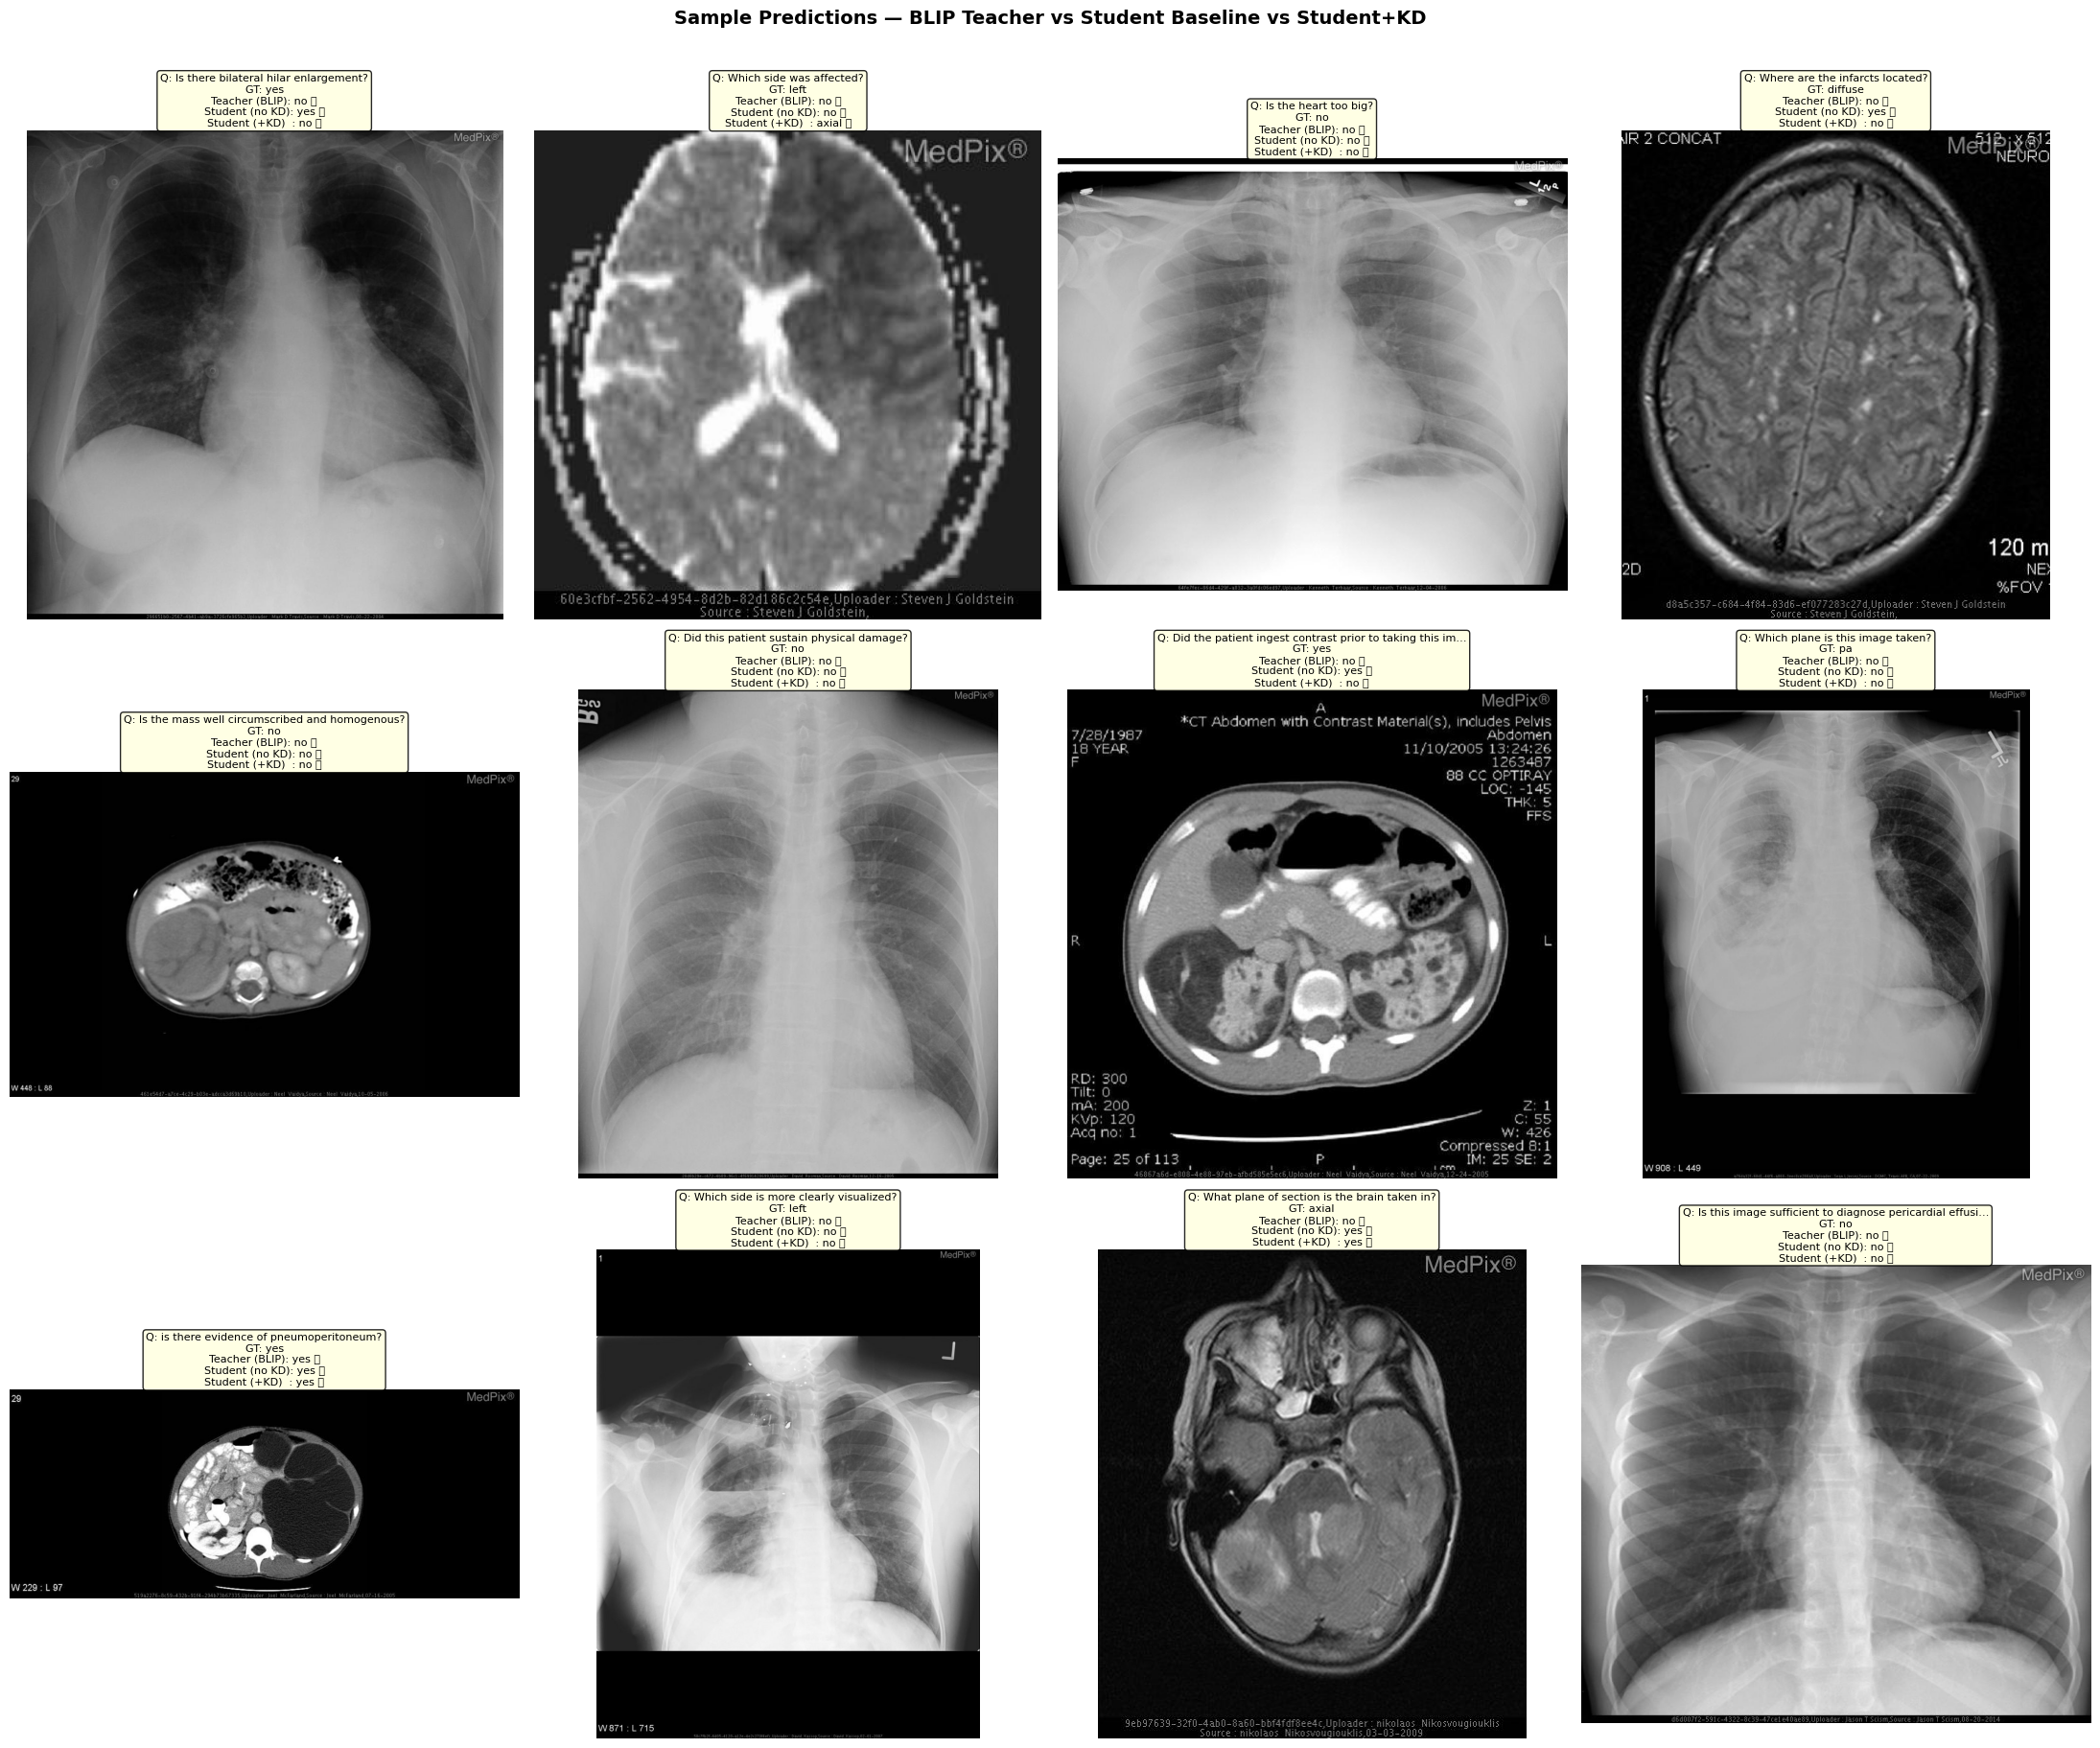

✅ Saved: sample_predictions.png


In [28]:
import matplotlib.pyplot as plt

@torch.no_grad()
def get_predictions_sample(teacher, student_bl, student_kd, dataset, n=12, device=DEVICE):
    teacher.eval(); student_bl.eval(); student_kd.eval()
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    results = []
    for idx in indices:
        item        = dataset[idx]
        pil_img     = item['pil_img']
        mobile_img  = item['mobile_img'].unsqueeze(0).to(device)
        label       = item['label'].item()
        question    = item['question']

        pv = process_blip_batch([pil_img], [question], device)
        t_logits,  _ = teacher(pv)
        sb_logits, _ = student_bl(mobile_img)
        kd_logits, _ = student_kd(mobile_img)

        results.append({
            'image_path'   : dataset.df.iloc[idx]['image_path'],
            'question'     : question,
            'true_answer'  : item['answer'],
            'teacher_pred' : le.classes_[t_logits.argmax(1).item()],
            'baseline_pred': le.classes_[sb_logits.argmax(1).item()],
            'kd_pred'      : le.classes_[kd_logits.argmax(1).item()],
        })
    return results


samples = get_predictions_sample(teacher, student_baseline, student_kd, test_ds, n=12)

n_cols = 4
n_rows = (len(samples) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 6))
axes = axes.flatten()

for i, s in enumerate(samples):
    ax = axes[i]
    try:
        img = Image.open(s['image_path']).convert('RGB')
        ax.imshow(img)
    except Exception:
        ax.set_facecolor('#111')

    gt   = s['true_answer']
    t    = s['teacher_pred']
    b    = s['baseline_pred']
    k    = s['kd_pred']
    t_ok = '\u2705' if t == gt else '\u274c'
    b_ok = '\u2705' if b == gt else '\u274c'
    k_ok = '\u2705' if k == gt else '\u274c'

    q_short = s['question'][:55] + ('\u2026' if len(s['question']) > 55 else '')
    title = (
        f"Q: {q_short}\n"
        f"GT: {gt}\n"
        f"Teacher (BLIP): {t} {t_ok}\n"
        f"Student (no KD): {b} {b_ok}\n"
        f"Student (+KD)  : {k} {k_ok}"
    )
    ax.set_title(title, fontsize=8, pad=3,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))
    ax.axis('off')

for j in range(len(samples), len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Predictions — BLIP Teacher vs Student Baseline vs Student+KD',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print("\u2705 Saved: sample_predictions.png")


## 13. Save All Models & Results

In [69]:
torch.save(teacher.state_dict(),          'teacher_blip_vqa.pth')
torch.save(student_baseline.state_dict(), 'student_mobilenet_baseline.pth')
torch.save(student_kd.state_dict(),       'student_mobilenet_kd.pth')

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("\u2705 Saved:")
for fn in ['teacher_blip_vqa.pth', 'student_mobilenet_baseline.pth',
           'student_mobilenet_kd.pth', 'label_encoder.pkl',
           'performance_metrics.csv', 'efficiency_metrics.csv',
           'sample_predictions.png']:
    print(f"   {fn}")

print("\n" + "\u2550"*60)
print("        \U0001f389 KNOWLEDGE DISTILLATION COMPLETE")
print("\u2550"*60)
print(f"  Teacher  (BLIP-VQA-base)   : {teacher_baseline_acc*100:.2f}%")
print(f"  Student  Baseline (No KD)  : {student_baseline_acc*100:.2f}%")
print(f"  Student  + KD              : {student_kd_acc*100:.2f}%  (+{(student_kd_acc-student_baseline_acc)*100:.2f}% gain)")
print(f"  Compression (params)       : {compression}× smaller than teacher")
print(f"  Inference speedup          : {speedup}×")
print("\u2550"*60)


✅ Saved:
   teacher_blip_vqa.pth
   student_mobilenet_baseline.pth
   student_mobilenet_kd.pth
   label_encoder.pkl
   performance_metrics.csv
   efficiency_metrics.csv
   sample_predictions.png

════════════════════════════════════════════════════════════
        🎉 KNOWLEDGE DISTILLATION COMPLETE
════════════════════════════════════════════════════════════
  Teacher  (BLIP-VQA-base)   : 57.87%
  Student  Baseline (No KD)  : 46.76%
  Student  + KD              : 54.17%  (+7.41% gain)
  Compression (params)       : 27.0× smaller than teacher
  Inference speedup          : 32.0×
════════════════════════════════════════════════════════════
